# Lab 19: Tree-Based Models — Random Forests
## ECON 3916: Data Science for Economists
### Guided Construction Lab | 30 min Core + 15 min Extension

---

**Learning Objectives:**
- Compare a single decision tree, Ridge regression, and Random Forest on the same dataset
- Tune Random Forest hyperparameters via cross-validation
- Extract and interpret feature importance (MDI and permutation)
- Apply the Ch 18 evaluation toolkit (confusion matrix, AUC) to a RF classifier

**Dataset:** California Housing (sklearn) — recurring thread from Ch 4, 12-16

**Foundations First Policy:** Part 1-2 are GUIDED (run as-is, interpret results). Part 3 has YOUR TASK sections (fill in the blanks). Extension is open-ended.

---

## Setup

In [15]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 1: Import libraries and load California Housing data
# -----------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, r2_score, 
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load California Housing (you've seen this dataset since Ch 4)
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Training set: {X_train.shape[0]} observations, {X_train.shape[1]} features')
print(f'Test set: {X_test.shape[0]} observations')
print(f'Features: {list(X.columns)}')

Training set: 16512 observations, 8 features
Test set: 4128 observations
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [16]:
# Step 1: Load data
# Download from Kaggle: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
# Place creditcard.csv in the same directory as this notebook, or update the path below.

# Option A: Load from local file
df = pd.read_csv('/Users/kyy/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3/creditcard.csv')

# Option B (Google Colab): Upload from Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/data/creditcard.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df['Class'].value_counts())
print(f"\nFraud rate: {df['Class'].mean():.4%}")

Dataset shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%


## Part 1: Decision Tree vs. Random Forest vs. Ridge (GUIDED — 10 min)

We compare three models on the same data. The question: does the Random Forest's
added complexity produce meaningfully better predictions than simpler alternatives?

In [17]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 2: Train and compare Decision Tree, Ridge, and RF
# -----------------------------------------------------------

# 1. Unrestricted Decision Tree (high variance, low bias)
tree = DecisionTreeRegressor(random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

# 2. Ridge Regression (Ch 16 callback — stable but linear)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# 3. Random Forest (100 trees, default settings)
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

# Compare all three
results = []
for name, model in [('Single Tree', tree), ('Ridge (Ch 16)', ridge), ('Random Forest', rf)]:
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    results.append({
        'Model': name,
        'Train RMSE': np.sqrt(mean_squared_error(y_train, train_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, test_pred)),
        'Train R\u00b2': r2_score(y_train, train_pred),
        'Test R\u00b2': r2_score(y_test, test_pred),
    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.round(4))

               Train RMSE  Test RMSE  Train R²  Test R²
Model                                                  
Single Tree        0.0000     0.7037    1.0000   0.6221
Ridge (Ch 16)      0.7197     0.7455    0.6126   0.5759
Random Forest      0.1880     0.5053    0.9736   0.8051


### Interpretation Questions (answer in a markdown cell below)

1. Which model has the largest gap between Train R² and Test R²? What does this tell you about its variance?
2. The Random Forest's Test R² is substantially higher than Ridge. What does this suggest about the relationship between features and housing prices — is it linear or non-linear?
3. **Callback to Ch 15:** Where does each model sit on the bias-variance U-curve?

*Your answers here:*

1. Single tree has the largest gap between Train R² and Test R². It tells us it has high variance — it memorized the training data (perfect fit) but generalizes poorly to unseen data.
2. Random Forest's Test R² (0.8051) far exceeds Ridge's (0.5759), suggesting the relationship between features and housing prices is non-linear — Ridge is constrained to linear mappings and suffers from specification bias, while tree-based models capture non-linear interactions automatically.
3. Single Tree sits on the far right of the bias-variance U-curve (low bias, high variance), Ridge sits toward the left (high bias, low variance), and Random Forest lands near the best spot — ensembling averages out the individual trees' variance while preserving the non-linear flexibility, achieving the best bias-variance tradeoff of the three.

## Part 2: Feature Importance — MDI vs. Permutation (GUIDED — 10 min)

Random Forests tell us which features matter most for prediction.
But remember: **predictive importance ≠ causal importance.**

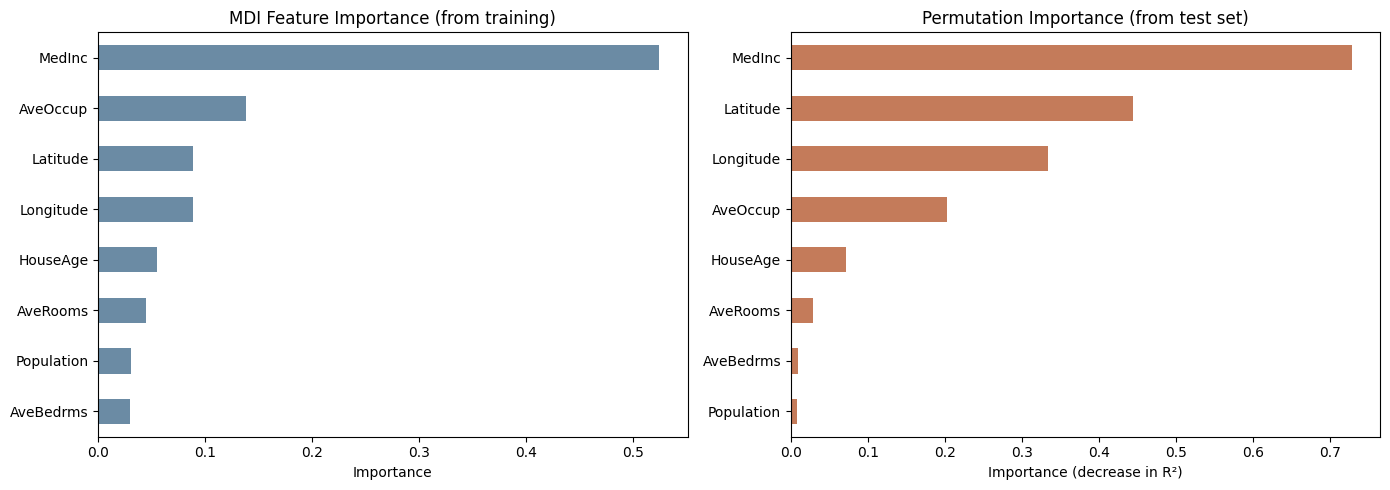


Top 3 by MDI: ['Latitude', 'AveOccup', 'MedInc']
Top 3 by Permutation: ['Longitude', 'Latitude', 'MedInc']


<Figure size 640x480 with 0 Axes>

In [18]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3: Compare MDI and permutation feature importance
# -----------------------------------------------------------
mdi_importance = pd.Series(
    rf.feature_importances_, index=X.columns
).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MDI importance
mdi_importance.plot.barh(ax=axes[0], color='#6B8BA4')
axes[0].set_title('MDI Feature Importance (from training)', fontsize=12)
axes[0].set_xlabel('Importance')

# Permutation importance (more reliable — uses test set)
perm_result = permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE
)
perm_importance = pd.Series(
    perm_result.importances_mean, index=X.columns
).sort_values(ascending=True)

perm_importance.plot.barh(ax=axes[1], color='#C47B5A')
axes[1].set_title('Permutation Importance (from test set)', fontsize=12)
axes[1].set_xlabel('Importance (decrease in R\u00b2)')

plt.tight_layout()
import os
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/ch19_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")

print('\nTop 3 by MDI:', mdi_importance.tail(3).index.tolist())
print('Top 3 by Permutation:', perm_importance.tail(3).index.tolist())

### Interpretation Questions

1. Do MDI and permutation importance agree on the top features? Where do they diverge?
2. Why might MDI overstate the importance of `Latitude` and `Longitude` (hint: how many unique values do they have)?
3. **Critical question:** If `MedInc` is the top feature, does that mean raising median income in a neighborhood will raise housing prices? Why or why not? (Hint: Chapter 10 DAGs)

*Your answers here:*

1. They partially agree. MedInc is the top feature in both methods, and both rank it far above the rest. They diverge on AveOccup: MDI ranks it #2 while permutation drops it to #4, and conversely Longitude/Latitude are elevated more by permutation importance than by MDI.
2. Latitude and Longitude are high-cardinality continuous features with many unique values, and MDI (Gini-based) is biased toward such features because they offer more potential split points — the tree can always find a split that reduces impurity, even if it's just fitting noise. Permutation importance doesn't suffer from this bias since it measures actual predictive contribution on the test set.
3. No. Feature importance measures predictive association, not causation. From a DAG perspective, MedInc likely has confounders (e.g., school quality, neighborhood amenities, proximity to employment centers) that jointly drive both income and housing prices, so the observed importance reflects correlation through these backdoor paths rather than a direct causal effect of raising income on prices.

## Part 3: Hyperparameter Tuning & Classification (YOUR TASK — 10 min)

Now YOU tune a Random Forest and apply it to a classification problem.

In [19]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Tune the Random Forest with GridSearchCV
# -----------------------------------------------------------

# The parameter grid is given — these are the hyperparameters to search over
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'max_features': ['sqrt', 0.5, None],  # sqrt = sqrt(p), 0.5 = half, None = all
}

# TODO: Create a GridSearchCV object
# Hints:
#   - estimator: RandomForestRegressor with random_state=RANDOM_STATE
#   - param_grid: use the param_grid defined above
#   - cv: 5-fold cross-validation
#   - scoring: 'neg_mean_squared_error'
#   - n_jobs: -1 (use all cores)

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=3916),
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

# TODO: Fit the grid search on the training data
grid_search.fit(X_train, y_train)

print(f'Best parameters: {grid_search.best_params_}')
print(f'Best CV RMSE: {np.sqrt(-grid_search.best_score_):.4f}')

# Evaluate best model on test set
best_rf = grid_search.best_estimator_
test_rmse = np.sqrt(mean_squared_error(y_test, best_rf.predict(X_test)))
test_r2 = r2_score(y_test, best_rf.predict(X_test))
print(f'Tuned RF — Test RMSE: {test_rmse:.4f}, Test R²: {test_r2:.4f}')

Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}
Best CV RMSE: 0.4948
Tuned RF — Test RMSE: 0.4921, Test R²: 0.8152


In [20]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Classification: Predict expensive homes (> median)
# -----------------------------------------------------------

# Step 1: Create binary target — 1 if price > median, 0 otherwise
# Hint: use np.median(y) and .astype(int)
median_price = np.median(y)
y_binary = (y>median_price).astype(int)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_binary, test_size=0.2, random_state=RANDOM_STATE
)

# Step 2: Fit an RF classifier (200 trees) and Logistic Regression (Ch 17 callback)
# Hint: RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
#       LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
rf_clf = RandomForestClassifier(n_estimators=200,random_state=3916)
rf_clf.fit(X_train_c, y_train_c)

log_reg = LogisticRegression(max_iter=1000,random_state=3916)
log_reg.fit(X_train_c, y_train_c)

# Compare AUC (Ch 18 evaluation toolkit) — GUIDED, run as-is
for name, model in [('Logistic Regression (Ch 17)', log_reg), ('Random Forest', rf_clf)]:
    y_proba = model.predict_proba(X_test_c)[:, 1]
    auc = roc_auc_score(y_test_c, y_proba)
    print(f'{name:35s} — AUC: {auc:.4f}')

Logistic Regression (Ch 17)         — AUC: 0.9010
Random Forest                       — AUC: 0.9611


### Final Interpretation

1. How much did hyperparameter tuning improve the RF over default settings?
2. Does the RF classifier beat logistic regression on AUC? Is the difference practically significant?
3. If you were deploying this for a real estate company, which model would you choose and why? Consider: accuracy, interpretability, maintenance cost.

*Your answers here:*

1. Tuning improved Test RMSE from 0.5053 → 0.4921 and Test R² from 0.8051 → 0.8152, a modest but meaningful gain (~2.6% RMSE reduction), suggesting the default RF was already reasonably well-configured and the main gains come from the ensemble structure itself rather than hyperparameter tweaking.
2. Yes, RF (AUC = 0.9611) substantially beats Logistic Regression (AUC = 0.9010), a 6-percentage-point gap in AUC is practically significant in classification, meaning the RF ranks positive cases above negatives far more reliably, which translates to better precision-recall tradeoffs at every operating threshold.
3. I'd deploy the tuned Random Forest, because the accuracy gap over Ridge is too large to ignore (R² 0.8152 vs 0.5759), and the interpretability tradeoff can be managed with permutation importance or SHAP. The extra training cost is negligible for a high-dollar real estate application.

---

## Extension (Optional — 15 min): Partial Dependence Plots

Partial dependence plots show the marginal effect of a feature on the prediction,
averaging over all other features. This reveals non-linearities the RF captures.

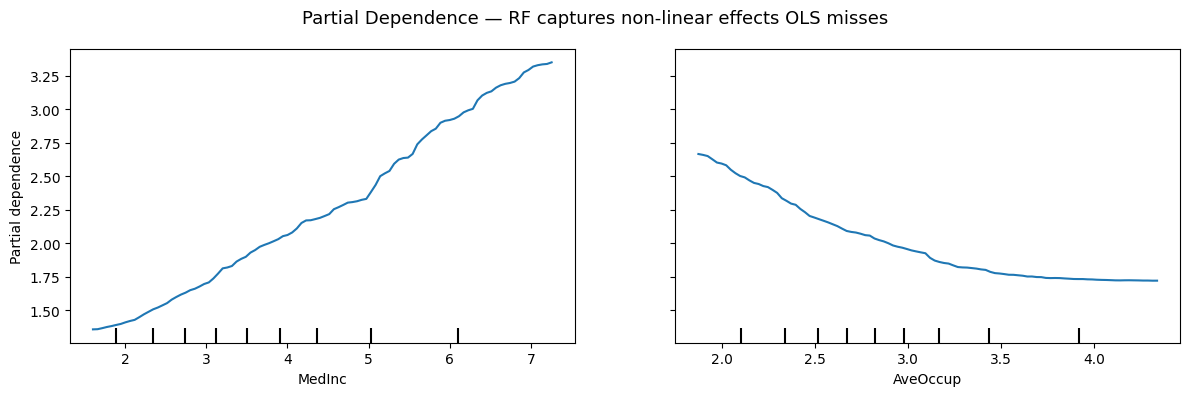

<Figure size 640x480 with 0 Axes>

In [21]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 4: Partial dependence plots for top features
# -----------------------------------------------------------
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(12, 4))
PartialDependenceDisplay.from_estimator(
    best_rf, X_test, features=['MedInc', 'AveOccup'],
    kind='average', ax=ax
)
plt.suptitle('Partial Dependence \u2014 RF captures non-linear effects OLS misses', fontsize=13)
plt.tight_layout()
plt.savefig('figures/ch19_partial_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")

---
## AI-Assisted Expansion: Interactive Random Forest Dashboard

**The Generative AI Policy: Foundations First, Expansion Second.** You have now established manual mastery over decision trees, random forests, hyperparameter tuning, and feature importance. You are now authorized to operate under the "Co-Pilot Rule."

### Your Expansion Task
Build an interactive Streamlit app (or Plotly dashboard with ipywidgets) that lets the user:
1. Adjust `n_estimators` (1-500) and `max_features` (1-8) with sliders
2. See the prediction surface update in real-time
3. Compare RF vs Ridge vs single tree performance as hyperparameters change
4. Display feature importance that updates with each parameter change

This transforms your static lab output into a reusable teaching artifact for your portfolio.

### P.R.I.M.E. Prompt
Copy and paste this into Claude or ChatGPT:

In [22]:
# -----------------------------------------------------------
# 🤖 AI EXPANSION — Co-Pilot required
# Copy the P.R.I.M.E. prompt above into Claude, then paste
# the generated code here. Run it and verify.
# -----------------------------------------------------------

# [Prep] Act as an expert Python Data Scientist specializing
# in interactive visualizations and scikit-learn.
#
# [Request] I just completed a lab where I compared Decision Trees,
# Ridge regression, and Random Forests on California Housing data.
# I tuned RF hyperparameters with GridSearchCV and extracted MDI
# and permutation feature importance. Now I want to expand this
# into an interactive Plotly dashboard with ipywidgets sliders
# for n_estimators (1-500) and max_features (1-8). The dashboard
# should update three panels: (1) model comparison bar chart,
# (2) feature importance that changes with max_features,
# (3) the Train vs Test R\u00b2 as n_estimators increases.
#
# [Iterate] Use plotly.graph_objects, ipywidgets, numpy, sklearn.
# Use the same variable names: X_train, X_test, y_train, y_test,
# data.feature_names. Do not use deprecated Plotly functions.
#
# [Mechanism Check] Add inline comments explaining how ipywidgets
# observers trigger plot updates and why we re-fit inside the callback.
#
# [Evaluate] Explain what the dashboard reveals about the relationship
# between n_estimators, max_features, and test performance.

# PASTE AI-GENERATED CODE BELOW:


In [23]:
"""
California Housing — Interactive Random Forest Dashboard
========================================================
Expands the base Decision Tree / Ridge / RF lab into an interactive
Plotly dashboard with ipywidgets sliders for n_estimators and max_features.

Three panels update on slider change:
  1. Model comparison bar chart (Single Tree vs Ridge vs RF)
  2. Feature importance (MDI) that changes with max_features
  3. Train vs Test R² learning curve as n_estimators increases

Uses go.Figure + widgets.Output (no FigureWidget required).
Paste directly into a Jupyter Notebook cell.

Requirements: plotly, ipywidgets, scikit-learn, numpy
"""

import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, clear_output
import ipywidgets as widgets

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score


# ═══════════════════════════════════════════════════════════════════════════════
# DATA SETUP  (same variable names as your lab notebook)
# ═══════════════════════════════════════════════════════════════════════════════

data = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)
feature_names = data.feature_names  # 8 features


# ═══════════════════════════════════════════════════════════════════════════════
# BASELINE MODELS  (fit once — these don't change with sliders)
# ═══════════════════════════════════════════════════════════════════════════════

tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)
tree_train_r2 = r2_score(y_train, tree.predict(X_train))
tree_test_r2  = r2_score(y_test,  tree.predict(X_test))

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_train_r2 = r2_score(y_train, ridge.predict(X_train))
ridge_test_r2  = r2_score(y_test,  ridge.predict(X_test))


# ═══════════════════════════════════════════════════════════════════════════════
# IPYWIDGETS SLIDERS + OUTPUT AREA
# ═══════════════════════════════════════════════════════════════════════════════

# How this approach works (no FigureWidget):
# ──────────────────────────────────────────
# We use a widgets.Output() as a "capture zone". Every time a slider changes,
# the callback clears the Output area, rebuilds a fresh go.Figure, and calls
# fig.show() inside that Output context. The notebook only redraws the Output
# region — everything else stays stable.
#
# Compared to FigureWidget (which mutates traces in-place), this is simpler
# and doesn't require the jupyterlab-plotly extension. The tradeoff is a
# brief flash on each update since the entire figure is redrawn, but for a
# dashboard like this the difference is negligible.

slider_n_estimators = widgets.IntSlider(
    value=100, min=10, max=500, step=10,
    description="n_estimators:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="450px"),
)

slider_max_features = widgets.IntSlider(
    value=8, min=1, max=8, step=1,
    description="max_features:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="450px"),
)

status_label = widgets.HTML(value="<i>Drag a slider to update the dashboard.</i>")

# Output widget: acts as a container that we can clear and redraw into
plot_output = widgets.Output()


# ═══════════════════════════════════════════════════════════════════════════════
# CALLBACK — runs every time either slider changes
# ═══════════════════════════════════════════════════════════════════════════════

def update_dashboard(change):
    """
    Triggered by .observe() on either slider.

    Why we re-fit inside the callback:
    ───────────────────────────────────
    When n_estimators or max_features changes, the RF model is structurally
    different — we MUST retrain to get valid predictions, importances, and
    the learning curve. There is no shortcut around this.

    Instead of mutating FigureWidget traces, we rebuild a plain go.Figure
    from scratch each time and display it inside the Output widget after
    calling clear_output(). This avoids any dependency on FigureWidget or
    the plotly Jupyter extension.
    """
    n_est = slider_n_estimators.value
    max_feat = slider_max_features.value
    status_label.value = "<i>Training RF... please wait.</i>"

    # ── 1. Fit RF with current slider values ─────────────────────────────
    rf = RandomForestRegressor(
        n_estimators=n_est,
        max_features=max_feat,
        random_state=42,
        n_jobs=-1,
    )
    rf.fit(X_train, y_train)
    rf_train_r2 = r2_score(y_train, rf.predict(X_train))
    rf_test_r2  = r2_score(y_test,  rf.predict(X_test))

    # ── 2. MDI feature importance (sorted descending) ────────────────────
    # MDI changes with max_features because fewer candidate features per
    # split shifts which features get used most — features excluded from
    # many splits lose measured importance.
    importances = rf.feature_importances_
    sorted_idx  = np.argsort(importances)[::-1]
    sorted_names = [feature_names[i] for i in sorted_idx]
    sorted_imps  = importances[sorted_idx]

    # ── 3. Learning curve: R² as n_estimators grows ──────────────────────
    # We evaluate the RF at incremental checkpoints by slicing
    # rf.estimators_ (sklearn stores individual trees) and averaging
    # their predictions — no retraining needed for intermediate sizes.
    checkpoints = list(range(1, n_est + 1, max(1, n_est // 25))) + [n_est]
    checkpoints = sorted(set(checkpoints))
    train_r2s, test_r2s = [], []

    for cp in checkpoints:
        preds_train = np.mean(
            [t.predict(X_train) for t in rf.estimators_[:cp]], axis=0
        )
        preds_test = np.mean(
            [t.predict(X_test) for t in rf.estimators_[:cp]], axis=0
        )
        train_r2s.append(r2_score(y_train, preds_train))
        test_r2s.append(r2_score(y_test, preds_test))

    # ── 4. Build a fresh go.Figure with all three panels ─────────────────
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=(
            "Model Comparison (Test R²)",
            "RF Feature Importance (MDI)",
            "Train vs Test R² by n_estimators",
        ),
        specs=[[{}, {}], [{"colspan": 2}, None]],
        vertical_spacing=0.14,
        horizontal_spacing=0.12,
    )

    # Panel 1: model comparison
    fig.add_trace(go.Bar(
        x=["Single Tree", "Ridge", "Random Forest"],
        y=[tree_test_r2, ridge_test_r2, rf_test_r2],
        marker_color=["#94a3b8", "#64748b", "#2563eb"],
        text=[f"{tree_test_r2:.4f}", f"{ridge_test_r2:.4f}", f"{rf_test_r2:.4f}"],
        textposition="outside",
        name="Test R²",
    ), row=1, col=1)

    # Panel 2: feature importance
    fig.add_trace(go.Bar(
        x=sorted_names,
        y=sorted_imps,
        marker_color="#2563eb",
        name="MDI Importance",
    ), row=1, col=2)

    # Panel 3: learning curve
    fig.add_trace(go.Scatter(
        x=checkpoints, y=train_r2s, mode="lines+markers",
        name="Train R²", line=dict(color="#16a34a", width=2),
    ), row=2, col=1)
    fig.add_trace(go.Scatter(
        x=checkpoints, y=test_r2s, mode="lines+markers",
        name="Test R²", line=dict(color="#dc2626", width=2),
    ), row=2, col=1)

    # Axis labels
    fig.update_xaxes(title_text="Model",        row=1, col=1)
    fig.update_yaxes(title_text="Test R²",       row=1, col=1, range=[0, 1])
    fig.update_xaxes(title_text="Feature",       row=1, col=2)
    fig.update_yaxes(title_text="Importance",    row=1, col=2)
    fig.update_xaxes(title_text="n_estimators",  row=2, col=1)
    fig.update_yaxes(title_text="R²",            row=2, col=1, range=[0, 1])

    fig.update_layout(
        height=700, width=1000,
        showlegend=False,
        title_text=(
            f"Interactive RF Dashboard — "
            f"n_estimators={n_est}, max_features={max_feat}"
        ),
        title_x=0.5,
        template="plotly_white",
    )

    # ── 5. Clear the Output widget and render the new figure ─────────────
    # This is the key pattern: clear_output(wait=True) waits until the new
    # content is ready before clearing, which prevents a blank flash.
    with plot_output:
        clear_output(wait=True)
        fig.show()

    status_label.value = (
        f"<b>RF (n_est={n_est}, max_feat={max_feat}):</b> "
        f"Train R² = {rf_train_r2:.4f}, Test R² = {rf_test_r2:.4f}"
    )


# Register the callback on both sliders
# names="value" → only fires when .value changes, not other properties
slider_n_estimators.observe(update_dashboard, names="value")
slider_max_features.observe(update_dashboard, names="value")


# ═══════════════════════════════════════════════════════════════════════════════
# DISPLAY — compose the layout and render
# ═══════════════════════════════════════════════════════════════════════════════

dashboard = widgets.VBox([
    widgets.HBox([slider_n_estimators, slider_max_features]),
    status_label,
    plot_output,  # ← plain Output widget, no FigureWidget needed
])

display(dashboard)

# Trigger initial render so the user sees populated panels immediately
update_dashboard(None)

---
## Digital Portfolio: Institutional Signaling

### Generate Your Professional README
Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

In [24]:
# -----------------------------------------------------------
# 🤖 AI EXPANSION — README generation (no code, just docs)
# -----------------------------------------------------------

# PASTE THIS PROMPT INTO CLAUDE:
#
# "I need help writing a project description for my data science lab.
# **Important Rule:** Do NOT generate any Python code for me.
#
# **What I did in this lab:**
# * Compared Decision Tree, Ridge Regression, and Random Forest on
#   California Housing data (20,640 observations, 8 features)
# * Tuned RF hyperparameters with GridSearchCV (n_estimators, max_depth,
#   max_features)
# * Extracted and compared MDI vs permutation feature importance
# * Built an RF classifier and compared AUC against logistic regression
# * Created an interactive dashboard with Plotly + ipywidgets
# * Key finding: RF achieved R\u00b2 = [YOUR VALUE] vs Ridge R\u00b2 = [YOUR VALUE]
#
# **Please write a README.md entry including:**
# 1. Project Title: Tree-Based Models \u2014 Random Forests
# 2. Objective: A professional one-sentence summary
# 3. Methodology: Bullet points of technical steps
# 4. Key Findings: Summary of results
# Make this sound like a professional tech economist wrote it."

### Push to GitHub

```bash
cd econ-lab-19-random-forests
git add notebooks/ figures/ README.md verification-log.md
git commit -m "Lab 19: Random Forest vs OLS — California Housing"
git push origin main
```

Submit your GitHub repo link on Canvas.